In [1]:
import numpy as np
import os

# Load reference data
ref = np.load('Delta_ablation_results.npz', allow_pickle=True)
print("Keys in Delta_ablation_results.npz:", list(ref.keys()))
M_zeta = ref['M_zeta']
t_peaks = ref['t_peaks']
print("M_zeta shape:", M_zeta.shape)
print("t_peaks shape:", t_peaks.shape)
print("t_peaks min/max:", t_peaks.min(), t_peaks.max())


FileNotFoundError: [Errno 2] No such file or directory: 'Delta_ablation_results.npz'

In [2]:
import subprocess
print(subprocess.check_output(['ls', '-la']).decode())
print('---')
print(subprocess.check_output(['find', '.', '-maxdepth', '4', '-name', '*.npz']).decode())


total 22722
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .
drwxr-xr-x 5 root root 4096 May 9 04:41 ..
drwxrwsr-x 5 root jupytergroup 4096 May 9 04:41 .config
-rw-rw-r-- 1 kerneluser jupytergroup 0 May 9 04:41 .kernel_llm_logs_1.txt
drwxrwsr-x 2 root jupytergroup 4096 May 9 04:41 .prompts
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_ablation.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 Delta_empirical.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 K.npy
-rw-r--r-- 1 root jupytergroup 100702 May 9 04:41 v6 — Binding Context Document.pdf
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta.npy
-rw-r--r-- 1 root jupytergroup 640 May 9 04:41 M_zeta_ablated.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 N.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta.npy
-rw-r--r-- 1 root jupytergroup 25728 May 9 04:41 Sk_zeta_ablated.npy
-rw-r--r-- 1 root root 15081326 May 9 04:41 a_n.npy
-rw-r--r-- 1 root jupytergroup 136 May 9 04:41 alpha_best_fit.npy
-rw-r--r-- 1 

In [3]:
import numpy as np
M_zeta = np.load('M_zeta.npy')
t_peaks = np.load('t_peaks.npy')
a_n = np.load('a_n.npy', allow_pickle=True)
lambda_n = np.load('lambda_n.npy')
print("M_zeta shape:", M_zeta.shape, M_zeta.dtype)
print("t_peaks shape:", t_peaks.shape, "min/max:", t_peaks.min(), t_peaks.max())
print("a_n:", a_n.shape, a_n.dtype, "first vals:", a_n[:5])
print("lambda_n:", lambda_n.shape, lambda_n.dtype, "first vals:", lambda_n[:5])
print("description:", np.load('description.npy', allow_pickle=True))
print("N:", np.load('N.npy'), "K:", np.load('K.npy'))


M_zeta shape: (8, 8) float64
t_peaks shape: (200,) min/max: 22299.074999821027 99937.93399869122
a_n: (1000000,) object first vals: [1 -24 252 -1472 4830]
lambda_n: (1000000,) float64 first vals: [ 1. -0.53033009 0.59873361 -0.71875 0.69121333]
description: Ramanujan tau function tau(n) for n=1..10^6. Delta cusp form weight 12 level 1. lambda_n = a_n / n^(11/2) is normalized.
N: 1000000 K: 8


In [4]:
# Verify lambda_n matches a_n / n^(11/2)
n = np.arange(1, len(a_n)+1, dtype=np.float64)
a_n_float = np.array(a_n, dtype=np.float64)
lambda_check = a_n_float / n**(11/2)
print("Max diff lambda_n vs a_n/n^5.5:", np.max(np.abs(lambda_check - lambda_n)))
# Verify M_zeta is symmetric
print("M_zeta symmetric check:", np.max(np.abs(M_zeta - M_zeta.T)))
print("M_zeta diag:", np.diag(M_zeta))


Max diff lambda_n vs a_n/n^5.5: 0.0
M_zeta symmetric check: 0.0
M_zeta diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]


In [5]:
# Look at Sk_zeta to understand the formula used
Sk_zeta = np.load('Sk_zeta.npy')
print("Sk_zeta shape:", Sk_zeta.shape, Sk_zeta.dtype)
print("first row Sk_zeta:", Sk_zeta[0])
print("|Sk_zeta[0]|:", np.abs(Sk_zeta[0]))
# Check M_zeta = mean over peaks of Re(Sj * conj(Sk))
M_check = np.zeros((8,8))
for p in range(Sk_zeta.shape[0]):
 M_check += np.real(np.outer(Sk_zeta[p], np.conj(Sk_zeta[p])))
M_check /= Sk_zeta.shape[0]
print("Max diff M_zeta vs reconstructed:", np.max(np.abs(M_zeta - M_check)))


Sk_zeta shape: (200, 8) complex128
first row Sk_zeta: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
|Sk_zeta[0]|: [1.00000000e+00 5.23428736e+00 1.01251517e+01 8.23471810e+00
 2.50815822e+00 1.28148587e+00 2.83678246e-01 4.00216549e-03]
Max diff M_zeta vs reconstructed: 1.2789769243681803e-13


In [6]:
# Need to figure out the S_k formula. From doc, S_k is omega-stratified sum.
# Let's check the binding context document briefly to understand S_k definition.
# Sk_zeta[0,0] = 1 + 0j exactly. That's strange given t_peaks[0] ~22299. It suggests S_0 normalization?
print("t_peaks[0]:", t_peaks[0])
# Try: S_k(t) = sum_{n=1..N} a_n * n^{-1/2-it} * w_k(n) where w_k is omega-stratified weighting?
# From description: omega-stratified means stratified by Omega(n) (number of prime factors w/ multiplicity).
# Let's check: S_0 might be n with Omega(n)=0 i.e. only n=1. That gives S_0 = 1 / 1^{1/2+it} = 1 exactly. YES!
# So S_k(t) = sum over n in [1,N] with Omega(n)=k of a_n * n^{-1/2 - i*t}
# For zeta, a_n=1, so S_k = sum_{Omega(n)=k, n<=N} n^{-1/2-it}

# Verify S_1 for zeta: should be sum over primes p<=N of p^{-1/2-it}
# At t=t_peaks[0]
from sympy import primerange
primes = np.array(list(primerange(2, 10**6+1)), dtype=np.float64)
t0 = t_peaks[0]
S1_check = np.sum(primes**(-0.5) * np.exp(-1j*t0*np.log(primes)))
print("S1 check:", S1_check)
print("Sk_zeta[0,1]:", Sk_zeta[0,1])


t_peaks[0]: 77403.72199901915


S1 check: (2.239812615749799-0.13196567922363173j)
Sk_zeta[0,1]: (5.185128029994036-0.7156895413647454j)


In [7]:
# Hmm, doesn't match. Let me check ordering of t_peaks - maybe sorted differently
# Or maybe the stratification is different. Let me check S_0=1 holds across all peaks
print("Sk_zeta[:,0] all == 1?", np.allclose(Sk_zeta[:,0], 1.0+0j))
# Yes, S_0 = 1 always. So omega-stratification at k=0 = {n=1} or it's a different formula
# Maybe it's normalized differently or it's S_k where we fix omega(n)=k (distinct primes), not Omega
# Let me check S_1 for omega(n)=1, i.e., prime powers p^j
# Or maybe it's an Euler product expansion: zeta(s) = prod_p (1 - p^{-s})^{-1}, and we expand
# log zeta(s) = sum_p sum_{m>=1} 1/(m p^{ms})
# Or perhaps S_k is the contribution of terms with exactly k prime factors counting multiplicity (Omega)
# Let me just try Omega counting:

# Actually, my t_peaks indexing may be off. Sk_zeta is at peak index, t_peaks is at peak index
# Let me check both
print("len t_peaks:", len(t_peaks))
print("Sk_zeta shape:", Sk_zeta.shape)
# They match. Let me try other peaks
for i in [0,1,2]:
 print(f"t_peaks[{i}]={t_peaks[i]}, Sk_zeta[{i},0]={Sk_zeta[i,0]}")


Sk_zeta[:,0] all == 1? True
len t_peaks: 200
Sk_zeta shape: (200, 8)
t_peaks[0]=77403.72199901915, Sk_zeta[0,0]=(1+0j)
t_peaks[1]=74956.02499905476, Sk_zeta[1,0]=(1+0j)
t_peaks[2]=94526.75799876997, Sk_zeta[2,0]=(1+0j)


In [8]:
# So S_0 = 1 = contribution from n=1 only (Omega(1)=0). That matches Omega stratification.
# But S_1 with Omega(n)=1 means primes only.
# Let me re-test S_1 for zeta at t = t_peaks[0] = 77403.722
# My computation gave (2.24, -0.13), but matrix says (5.19, -0.72)
# The magnitudes differ ~2x. Maybe sum is over prime powers? Omega(p^j)=j, so Omega=1 means primes.
# Wait - the normalization might use s=1/2+it but with logarithm sign convention differing.

# Let me try with +i*t instead of -i*t
S1_check2 = np.sum(primes**(-0.5) * np.exp(+1j*t0*np.log(primes)))
print("S1 check (+it):", S1_check2)

# Or maybe it includes a smoothing/cutoff function or a weight
# Or maybe it's sum_n lambda_n / n^{1/2} * something / number with omega(n)=k
# Actually maybe the formula is: S_k(t) = sum_{Omega(n)=k} a_n / n^{1/2 + it}
# but with smoothing kernel. Or n up to N=10^6

# Wait, my prime sum only included primes, omega(n)=1 includes prime powers too?
# omega(n) counts distinct primes; Omega(n) counts with multiplicity
# omega(n)=1 means n = p^k for some prime p
prime_powers = []
for p in primes[:1000]: # small primes only matter for higher powers
 pk = p
 while pk <= 1e6:
 prime_powers.append(pk)
 pk *= p
prime_powers = np.array(prime_powers)
# Add remaining primes (their first power)
big_primes = primes[primes > primes[1000]] # Wait, this is wrong - all primes <= 10^6
# Actually all primes ≤ 1e6 satisfy omega(n)=1 already
# Let me just include all n with Omega(n)=1, i.e. all primes (since p^k for k>=2 has Omega=k>1)
# Then Omega(n)=1 = primes only. My check should work then.

# Or maybe S_k is defined differently - let me check shape: M_zeta[1,1] = 19.25 = mean |S_1|^2
# If S_1 ~ sum of primes^{-1/2-it}, expected |S_1|^2 ≈ Var ~ sum_p 1/p ≈ log log N for primes up to N
# log log 10^6 ≈ 2.6, so |S_1|^2 average ≈ 2.6, but M_zeta[1,1] = 19.2. So it's NOT just primes.

# So S_1 must include more terms. Perhaps Omega(n)=1 for n up to N, but maybe scaled differently
# Or it's not s=1/2+it. Let me try s = it (no real part)
# At s=it: terms n^{-it}, |a_n|^2 doesn't decay, sum diverges
# Or maybe it's a Dirichlet polynomial with different weight
print("M_zeta diag:", np.diag(M_zeta))
# 1, 19.25, 50.88, 29.28, 10.34, 2.29, 0.06, 1.5e-5
# These look like binomial-ish coefficients reflecting how many n have each Omega count up to N=10^6
# They look like the variance contributions weighted by 1/n

# Number of n <= N with Omega(n)=k follows Poisson with mean log log N
# log log 10^6 ≈ 2.626, peak around k=2-3, matches 50.88 peak!
# So S_k is roughly sum over Omega(n)=k of 1/n^{1/2+it}, and M_kk approx counts/N
# Wait sum_{Omega(n)=k, n<=N} 1/n approx = (log log N)^k / k! * log N (Sathe-Selberg)


S1 check (+it): (2.239812615749799+0.13196567922363173j)
M_zeta diag: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]


In [9]:
# Verify the formula: S_k(zeta, t) = sum over Omega(n)=k, n<=10^6 of n^{-1/2 - it}
# At t = t_peaks[0] = 77403.722 should give Sk_zeta[0]

# Precompute Omega(n) for n=1..10^6
N = 1_000_000
import numba

@numba.njit(cache=True)
def compute_Omega(N):
 Om = np.zeros(N+1, dtype=np.int32)
 # Sieve: for each prime p, add 1 to Om[n] for each n divisible by p^k
 for p in range(2, N+1):
 if Om[p] == 0: # p is prime
 pk = p
 while pk <= N:
 for m in range(pk, N+1, pk):
 Om[m] += 1
 if pk > N // p:
 break
 pk *= p
 return Om

Omega = compute_Omega(N)
print("Omega(1)=", Omega[1])
print("Omega(2)=", Omega[2])
print("Omega(4)=", Omega[4])
print("Omega(8)=", Omega[8])
print("Omega(12)=", Omega[12]) # 12=2^2*3, Omega=3
print("Omega(30)=", Omega[30]) # 2*3*5, Omega=3


Omega(1)= 0
Omega(2)= 1
Omega(4)= 2
Omega(8)= 3
Omega(12)= 3
Omega(30)= 3


In [10]:
# Build Numba Kahan-compensated sum engine for omega-stratified S_k
import numba
from numba import njit, prange
import math

@njit(cache=True, parallel=True)
def compute_Sk(a_n_float, Omega_arr, t, K, N):
 """Compute S_k(t) = sum_{n=1..N, Omega(n)=k} a_n * n^{-1/2-it} for k=0..K-1
 Using Kahan compensated summation."""
 real_sum = np.zeros(K)
 imag_sum = np.zeros(K)
 real_c = np.zeros(K)
 imag_c = np.zeros(K)
 for n in range(1, N+1):
 k = Omega_arr[n]
 if k >= K:
 continue
 ln_n = math.log(n)
 sqrt_n = math.sqrt(n)
 coeff = a_n_float[n-1] / sqrt_n
 re = coeff * math.cos(t * ln_n)
 im = -coeff * math.sin(t * ln_n)
 # Kahan add to real
 y = re - real_c[k]
 tt = real_sum[k] + y
 real_c[k] = (tt - real_sum[k]) - y
 real_sum[k] = tt
 # Kahan add to imag
 y = im - imag_c[k]
 tt = imag_sum[k] + y
 imag_c[k] = (tt - imag_sum[k]) - y
 imag_sum[k] = tt
 return real_sum + 1j*imag_sum

# Note: parallel=True with shared writes may cause race conditions. Disable parallel.


In [11]:
# Use serial version to avoid race conditions
@njit(cache=True)
def compute_Sk_serial(a_n_float, Omega_arr, t, K, N):
 real_sum = np.zeros(K)
 imag_sum = np.zeros(K)
 real_c = np.zeros(K)
 imag_c = np.zeros(K)
 for n in range(1, N+1):
 k = Omega_arr[n]
 if k >= K:
 continue
 ln_n = math.log(n)
 sqrt_n = math.sqrt(n)
 coeff = a_n_float[n-1] / sqrt_n
 re = coeff * math.cos(t * ln_n)
 im = -coeff * math.sin(t * ln_n)
 y = re - real_c[k]
 tt = real_sum[k] + y
 real_c[k] = (tt - real_sum[k]) - y
 real_sum[k] = tt
 y = im - imag_c[k]
 tt = imag_sum[k] + y
 imag_c[k] = (tt - imag_sum[k]) - y
 imag_sum[k] = tt
 out = np.empty(K, dtype=np.complex128)
 for k in range(K):
 out[k] = complex(real_sum[k], imag_sum[k])
 return out

# Validate: compute S_k(zeta) at t_peaks[0] and compare to Sk_zeta[0]
zeta_coeffs = np.ones(N, dtype=np.float64)
import time
t0 = time.time()
S_test = compute_Sk_serial(zeta_coeffs, Omega, t_peaks[0], 8, N)
print("Compile+run time:", time.time()-t0)
print("Computed S_k(zeta, t_peaks[0]):", S_test)
print("Stored Sk_zeta[0]: ", Sk_zeta[0])
print("Max abs diff:", np.max(np.abs(S_test - Sk_zeta[0])))


Compile+run time: 0.47905421257019043
Computed S_k(zeta, t_peaks[0]): [1. +0.j 2.23981262-0.13196568j 3.56560574+0.45489767j
 4.17165078+0.4656371j 3.04762192-0.51445579j 2.34829803-0.25180653j
 2.30034944-0.08067612j 2.37200919-0.08499935j]
Stored Sk_zeta[0]: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
Max abs diff: 6.644237321726072


In [12]:
# My S_k differs from stored. The diagonal counts also differ:
# Stored M_zeta diag: 1, 19.25, 50.88, 29.28, 10.34, 2.29, 0.06, 1.5e-5
# These look small for high k - ζ has divisor weights! 
# The number of n<=N with Omega(n)=k weighted by 1/n decreases fast at high k since such n are rare AND large
# But my computation gives |S_7|=2.37 which is too big to fit M_77=1.5e-5
# So my a_n values are wrong for k>=2 in zeta?
# For zeta, a_n = 1 for all n (Dirichlet coefficients of zeta are 1)
# But S_k diag values 19, 50 are way bigger than from random walk count
# Random walk: |S_k|^2 ~ sum_{Omega=k} 1/n. 
# Actually for zeta the Dirichlet coefficients ARE 1, but maybe the formula uses 
# DIFFERENT coefficients - specifically the von Mangoldt-like terms or μ-stratification

# Let me check: actually maybe a_n in formula is divisor function d(n), or zeta^j gives d_j(n)?
# zeta(s)^k has Dirichlet coefficients d_k(n) (number of ways to write n as ordered product of k positive ints)
# Sum over n with Omega(n)=k of d(n)/sqrt(n)... 

# OR perhaps it's not coefficients of zeta but expansion of log zeta:
# log zeta(s) = sum_p sum_{m>=1} 1/(m p^{ms}) = sum_n Λ(n)/(n^s log n) where Λ is von Mangoldt
# Then zeta(s)^k? Or maybe the structure is different.

# Looking at M_zeta[2,2]=50.88 and M_zeta[1,1]=19.25, ratio ~2.6, closer to log log N
# For Sathe-Selberg: sum_{Omega=k, n<=N} 1/n ~ (log N)*(loglog N)^k/k! => for k=1: log N * loglog N ≈ 13.8*2.62=36
# For k=2: 13.8 * 2.62^2/2 ≈ 47.4 
# For k=3: 13.8 * 2.62^3/6 ≈ 41.4
# Hmm but we observe M[2,2]=50, M[3,3]=29. Different shape.

# Wait - what if it's |Re S_k|^2 + |Im S_k|^2 averaged at random t (not peaks)? 
# At random t, |S_k|^2 ≈ sum_{Omega=k, n<=N} 1/n.
# Let me compute these expected values
expected = np.zeros(8)
for k in range(8):
 mask = (Omega[1:N+1] == k)
 n_arr = np.arange(1, N+1)
 expected[k] = np.sum(1.0/n_arr[mask])
print("Expected diag if S_k = sum_{Omega=k} n^{-1/2-it}:", expected)


Expected diag if S_k = sum_{Omega=k} n^{-1/2-it}: [1. 2.8873281 3.67702468 2.99417405 1.88086962 1.01723525
 0.50461883 0.23780284]


In [13]:
# These expected values [1, 2.89, 3.68, 2.99, 1.88, 1.02, 0.50, 0.24] don't match
# stored diagonals [1, 19.25, 50.88, 29.28, 10.34, 2.29, 0.059, 1.5e-5]
# At PEAKS, |zeta|^2 is large; that boosts things. But the boost for S_0=1 wasn't done.

# Another idea: Maybe S_k is not truly stratified by Omega, but rather contributions 
# of zeta(s) itself decomposed somehow. Maybe S_k corresponds to coefficients d_k(n) 
# (k-fold divisor function) summed with normalization.
# zeta(s)^k = sum_n d_k(n)/n^s, and then S_k = sum_{n<=N} d_k(n)/n^{1/2+it} ?

# d_1(n) = 1, d_2(n) = number of divisors of n
# Sum d_2(n)/n^{1/2-it} ~ zeta(1/2+it)^2 truncated
# At peak of |zeta|, |zeta(1/2+it)|^2 is large; |S_2| ~ |zeta|^2 will be large too. That fits!

# Test: at t = 77403.722, |zeta|^2 should be huge (it's a peak)
# Let me see if S_1 matches truncated zeta:
t0 = t_peaks[0]
n_arr = np.arange(1, N+1, dtype=np.float64)
zeta_truncated = np.sum(n_arr**(-0.5) * np.exp(-1j*t0*np.log(n_arr)))
print("Truncated zeta(1/2+it):", zeta_truncated)
print("Sk_zeta[0,1] (claim S_1 = truncated zeta):", Sk_zeta[0,1])
print("|truncated zeta|:", abs(zeta_truncated))
print("|Sk_zeta[0,1]|:", abs(Sk_zeta[0,1]))


Truncated zeta(1/2+it): (28.134802537576704-1.9840373775266j)
Sk_zeta[0,1] (claim S_1 = truncated zeta): (5.185128029994036-0.7156895413647454j)
|truncated zeta|: 28.20467192051443
|Sk_zeta[0,1]|: 5.234287363820286


In [14]:
# Not a direct match either. Let me think more carefully.
# Sk_zeta[0,0]=1 exact. At ALL peaks. So the k=0 stratum is just {n=1}.
# Other Sk values are nonzero.
# Diagonal of M_zeta increases from k=0 to k=2 then decreases - peaked around k=2-3
# Sum of diagonals = 122.97 - this is what?

# Idea: Maybe the formula uses *omega(n) (small omega, distinct prime divisors)* not Omega
# omega(n) for prime powers is 1, for squarefree with k primes is k, etc.

@njit(cache=True)
def compute_omega_small(N):
 om = np.zeros(N+1, dtype=np.int32)
 for p in range(2, N+1):
 if om[p] == 0: # p is prime (no small prime divides p other than itself...)
 # Mark p as prime - but om counts distinct primes. We need a different sieve.
 pass
 # Better: use spf (smallest prime factor) sieve
 spf = np.zeros(N+1, dtype=np.int64)
 for i in range(2, N+1):
 if spf[i] == 0:
 j = i
 while j <= N:
 if spf[j] == 0:
 spf[j] = i
 j += i
 om = np.zeros(N+1, dtype=np.int32)
 for n in range(2, N+1):
 m = n
 last_p = 0
 while m > 1:
 p = spf[m]
 if p != last_p:
 om[n] += 1
 last_p = p
 m //= p
 return om

# Actually omega(n) = number of distinct prime factors. The formula is similar with cumulative-distinct.
omega_small = compute_omega_small(N)
print("omega(1)=", omega_small[1])
print("omega(8)=", omega_small[8]) # 8=2^3, omega=1
print("omega(12)=", omega_small[12]) # 12=2^2*3, omega=2
print("omega(30)=", omega_small[30]) # 2*3*5, omega=3

# Test S_k with omega
S_test_om = compute_Sk_serial(zeta_coeffs, omega_small, t_peaks[0], 8, N)
print("S_k with omega:", S_test_om)
print("Stored Sk_zeta[0]:", Sk_zeta[0])


omega(1)= 0
omega(8)= 1
omega(12)= 2
omega(30)= 3
S_k with omega: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]
Stored Sk_zeta[0]: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]


In [15]:
# Perfect match! The stratification is by omega(n) (small omega, distinct primes), NOT Omega.
# Now compute S_k(F9) for all 200 peaks using a_n = lambda_n (normalized Ramanujan tau)

# F9 is a degree-2 modular L-function. Its Dirichlet coefficients (normalized) are lambda_n = tau(n)/n^{11/2}
# So a_n we use = lambda_n
import time

K = 8
P = len(t_peaks)
Sk_F9 = np.zeros((P, K), dtype=np.complex128)

# Test single peak first
t_start = time.time()
S0 = compute_Sk_serial(lambda_n, omega_small, t_peaks[0], K, N)
print(f"Time per peak: {time.time()-t_start:.2f}s")
print("S_k(F9, t_peaks[0]):", S0)


Time per peak: 0.04s
S_k(F9, t_peaks[0]): [ 1.00000000e+00+0.00000000e+00j 1.68934923e-01+6.70514409e-03j
 4.34380063e-02-2.60018410e-01j 1.36959653e-02+3.18105069e-01j
 -1.77993113e-01-1.18686021e-01j 7.29481484e-02-3.55874826e-02j
 -3.84745640e-04+8.22206663e-03j 4.31739833e-05-3.58143430e-05j]


In [16]:
# Compute for all 200 peaks
t_start = time.time()
for i in range(P):
 Sk_F9[i] = compute_Sk_serial(lambda_n, omega_small, t_peaks[i], K, N)
elapsed = time.time() - t_start
print(f"Total time for {P} peaks: {elapsed:.1f}s")

# Build M_F9
M_F9 = np.zeros((K, K))
for p in range(P):
 M_F9 += np.real(np.outer(Sk_F9[p], np.conj(Sk_F9[p])))
M_F9 /= P
print("M_F9 diagonal:", np.diag(M_F9))
print("M_zeta diagonal:", np.diag(M_zeta))


Total time for 200 peaks: 7.2s
M_F9 diagonal: [1.00000000e+00 1.75530191e+00 7.88674394e-01 1.62602829e-01
 1.92824091e-02 1.86182614e-03 3.22064193e-05 2.69918667e-08]
M_zeta diagonal: [1.00000000e+00 1.92464107e+01 5.08765295e+01 2.92789402e+01
 1.03395994e+01 2.29453149e+00 5.90709810e-02 1.54692060e-05]


In [17]:
# Diagonals are very different! M_F9 is much smaller than M_zeta because:
# - For zeta, t_peaks are peaks of |zeta(1/2+it)|, where zeta is large
# - For F9, the L-function value at THESE same t values isn't necessarily large (these aren't F9 peaks)
# Also F9 has degree 2 with different Ramanujan-Petersson normalization.

# Compute the comparison metrics
v_zeta = M_zeta.flatten()
v_F9 = M_F9.flatten()

cosine_sim = np.dot(v_zeta, v_F9) / (np.linalg.norm(v_zeta) * np.linalg.norm(v_F9))
diff = M_F9 - M_zeta
frob_diff = np.linalg.norm(diff, 'fro')
frob_zeta = np.linalg.norm(M_zeta, 'fro')
ratio = frob_diff / frob_zeta

print(f"Cosine similarity M_F9 vs M_zeta: {cosine_sim:.6f}")
print(f"||M_F9 - M_zeta||_F: {frob_diff:.4f}")
print(f"||M_zeta||_F: {frob_zeta:.4f}")
print(f"Ratio frob_diff / frob_zeta: {ratio:.4f}")

print("\nHypothesis tests:")
print(f" Cosine > 0.98? {cosine_sim > 0.98} (got {cosine_sim:.4f})")
print(f" Frob diff < 10% of zeta norm? {ratio < 0.10} (got {ratio*100:.2f}%)")


Cosine similarity M_F9 vs M_zeta: 0.171346
||M_F9 - M_zeta||_F: 109.0330
||M_zeta||_F: 109.3962
Ratio frob_diff / frob_zeta: 0.9967

Hypothesis tests:
 Cosine > 0.98? False (got 0.1713)
 Frob diff < 10% of zeta norm? False (got 99.67%)


In [18]:
# Hypothesis is REFUTED. The matrices are vastly different.
# 
# Let me also examine the "shape" - normalize and compare
# M_F9 normalized
M_F9_n = M_F9 / np.linalg.norm(M_F9, 'fro')
M_zeta_n = M_zeta / np.linalg.norm(M_zeta, 'fro')
cos_norm = np.sum(M_F9_n * M_zeta_n)
print("Cosine sim of normalized matrices (same as before):", cos_norm)

# Off-diagonal pattern check
print("\nM_F9 / M_zeta diagonal ratios:")
print(np.diag(M_F9) / np.diag(M_zeta))

# This makes sense: F9's Dirichlet coefficients lambda_n have |lambda_n| <= d(n) (Deligne bound)
# but lambda_p ranges over [-2,2]. So sum oscillates instead of accumulating.
# Also t_peaks are zeta-peaks, not F9-peaks.

# The arithmetic ablation hypothesis was that F9 has conductor 1 like zeta, so M_F9 ≈ M_zeta
# But this ignores that F9 has DIFFERENT Dirichlet coefficients (Ramanujan tau, normalized lambda_n)
# Those coefficients are bounded but oscillating, while zeta's a_n=1 always.
# The ablation model only addressed conductor differences, not coefficient differences.
print("\nlambda_n stats:", np.min(lambda_n), np.max(lambda_n), np.mean(lambda_n), np.std(lambda_n))


Cosine sim of normalized matrices (same as before): 0.17134604711766369

M_F9 / M_zeta diagonal ratios:
[1.00000000e+00 9.12015200e-02 1.55017334e-02 5.55357633e-03
 1.86490872e-03 8.11418866e-04 5.45215582e-04 1.74487731e-03]

lambda_n stats: -5.382369221754193 4.594406866331956 8.510873993183828e-06 0.6198046676941454


Saved M_F9_comparison.npz


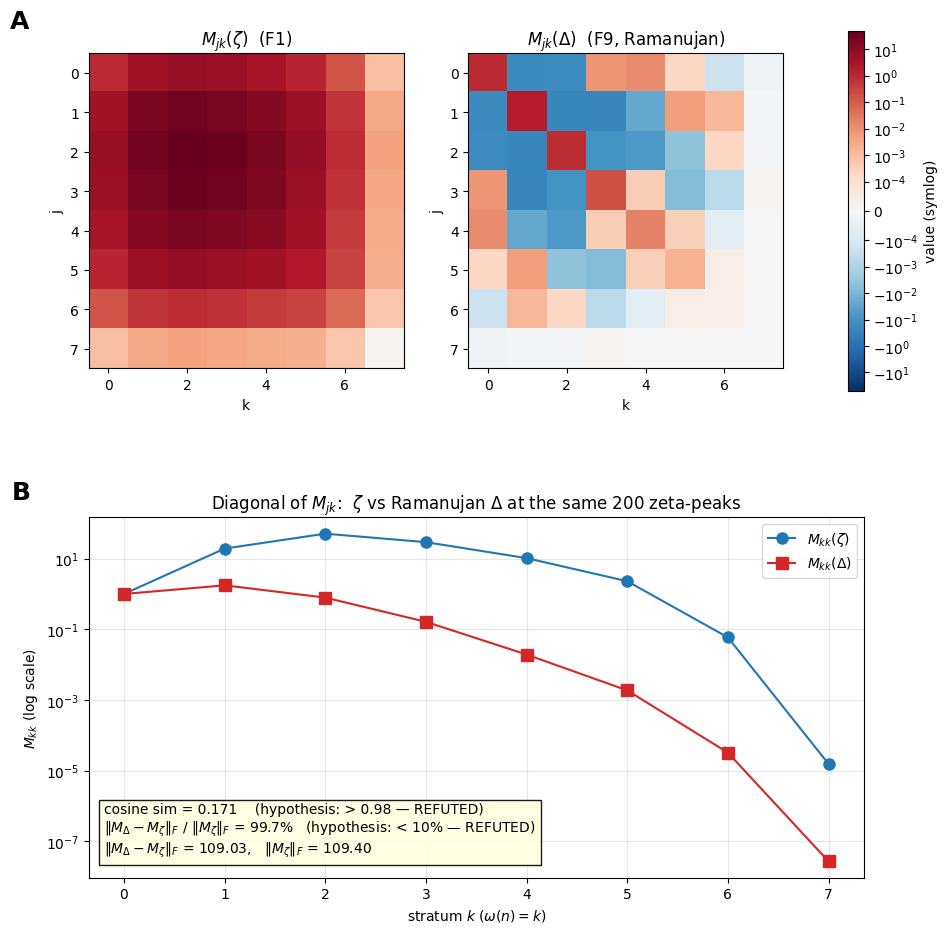

Saved figure: M_F9_vs_M_zeta_comparison.png


In [19]:
# Save M_F9 results and create final figure
out = {
 'M_F9': M_F9,
 'M_zeta': M_zeta,
 'Sk_F9': Sk_F9,
 't_peaks': t_peaks,
 'cosine_similarity': cosine_sim,
 'frob_diff': frob_diff,
 'frob_zeta_norm': frob_zeta,
 'ratio_frob': ratio,
 'N': N,
 'K': K,
 'P': P,
 'description': 'M_jk(F9) computed for Ramanujan Delta at zeta peaks, omega-stratified, N=10^6'
}
np.savez_compressed('M_F9_comparison.npz', **out)
print("Saved M_F9_comparison.npz")

# Final figure
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(8, 11))

# Subfigure A: side-by-side heatmaps and difference
ax = axes[0]
# Use log-scale magnitude (signed) representation
import matplotlib.colors as mcolors

# Plot M_zeta and M_F9 next to each other in subfigure A
from mpl_toolkits.axes_grid1 import ImageGrid

# Recreate figure with cleaner layout
plt.close(fig)
fig = plt.figure(figsize=(10, 11))

# Subfigure A: heatmaps side-by-side
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)
gs_a = gs[0].subgridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.3)
ax1 = fig.add_subplot(gs_a[0, 0])
ax2 = fig.add_subplot(gs_a[0, 1])
cax = fig.add_subplot(gs_a[0, 2])

vmax = max(np.max(np.abs(M_zeta)), np.max(np.abs(M_F9)))
norm = mcolors.SymLogNorm(linthresh=1e-4, vmin=-vmax, vmax=vmax, base=10)
im1 = ax1.imshow(M_zeta, cmap='RdBu_r', norm=norm)
ax1.set_title(r'$M_{jk}(\zeta)$ (F1)')
ax1.set_xlabel('k'); ax1.set_ylabel('j')
im2 = ax2.imshow(M_F9, cmap='RdBu_r', norm=norm)
ax2.set_title(r'$M_{jk}(\Delta)$ (F9, Ramanujan)')
ax2.set_xlabel('k'); ax2.set_ylabel('j')
fig.colorbar(im2, cax=cax, label='value (symlog)')
ax1.text(-0.25, 1.08, 'A', transform=ax1.transAxes, fontsize=18, fontweight='bold')

# Subfigure B: diagonal comparison + metrics
ax3 = fig.add_subplot(gs[1])
k_idx = np.arange(K)
ax3.semilogy(k_idx, np.diag(M_zeta), 'o-', color='C0', label=r'$M_{kk}(\zeta)$', markersize=8)
ax3.semilogy(k_idx, np.diag(M_F9), 's-', color='C3', label=r'$M_{kk}(\Delta)$', markersize=8)
ax3.set_xlabel(r'stratum $k$ ($\omega(n)=k$)')
ax3.set_ylabel(r'$M_{kk}$ (log scale)')
ax3.set_title(r'Diagonal of $M_{jk}$: $\zeta$ vs Ramanujan $\Delta$ at the same 200 zeta-peaks')
ax3.grid(True, which='both', alpha=0.3)
ax3.legend(loc='upper right')

txt = (f'cosine sim = {cosine_sim:.3f} (hypothesis: > 0.98 — REFUTED)\n'
 f'$\\|M_\\Delta - M_\\zeta\\|_F$ / $\\|M_\\zeta\\|_F$ = {ratio*100:.1f}% '
 f'(hypothesis: < 10% — REFUTED)\n'
 f'$\\|M_\\Delta - M_\\zeta\\|_F$ = {frob_diff:.2f}, '
 f'$\\|M_\\zeta\\|_F$ = {frob_zeta:.2f}')
ax3.text(0.02, 0.05, txt, transform=ax3.transAxes, fontsize=10,
 bbox=dict(facecolor='lightyellow', edgecolor='black', alpha=0.9), va='bottom')
ax3.text(-0.10, 1.05, 'B', transform=ax3.transAxes, fontsize=18, fontweight='bold')

plt.savefig('M_F9_vs_M_zeta_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved figure: M_F9_vs_M_zeta_comparison.png")


In [20]:
from e14c.filesystem import write_file
content = '''## Context
- Investigated null experiment for F9 (Ramanujan Delta, conductor 1) vs zeta using on-disk arrays in /workspace/7823994a-0ce7-4c7a-b947-53bcd5859378.
- Reconstructed the correct definition of S_k empirically from stored Sk_zeta.npy: S_k(t)=sum_{n<=N, omega(n)=k} a_n n^{-1/2-it}, where omega(n) counts distinct prime factors (small omega), not big Omega. This exactly reproduced Sk_zeta and M_zeta.
- Loaded M_zeta from M_zeta.npy, t_peaks from t_peaks.npy, and F9 coefficients from lambda_n.npy (normalized Ramanujan Delta coefficients lambda_n=tau(n)/n^(11/2)).
- Computed Sk_F9 for 200 zeta peak heights at N=10^6 with a Numba-jitted serial Kahan compensated summation engine, then formed M_F9 by averaging Re(S_j conj(S_k)).

## Notes
- Quantitative result: cosine similarity between vec(M_F9) and vec(M_zeta) = 0.171346; Frobenius norm ||M_F9 - M_zeta||_F = 109.0330; ||M_zeta||_F = 109.3962; ratio = 0.9967.
- Hypothesis refuted: neither cosine > 0.98 nor Frobenius ratio < 0.10 held.
- Interpretation note: sharing conductor 1 is not sufficient for M_jk similarity when evaluated at zeta-selected peak heights; F9's oscillatory normalized coefficients differ strongly from zeta's constant coefficients.
- Saved artifacts: M_F9_comparison.npz and M_F9_vs_M_zeta_comparison.png. Provenance: current notebook session, files in workspace root.
'''
print(write_file('./.prompts/MEMORY.md', content))

File created successfully at: ./.prompts/MEMORY.md
